In [1]:
using Revise
includet("../../scripts/single_influx.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Run the li=1 data

In [9]:
N = 20
M = N
B = 3

Ks = 10 .^ range(-0.5, 4.0, 50)
Ks = 10 .^ range(0.5, 4.0, 10)

li1df, li1cms = do_df_run(Ks, N;
    M,
    # Slightly random vars
    m=base10_lognormal(0.0, 0.001),
    c=base10_lognormal(0.0, 0.001),
    cinflux=base10_lognormal(0.0, 0.001),
    # Always eat influx with fixed l
    pei=1.0, linflux=1.0,
    # Eat rest with chance at no l
    pe=(B / M), l=0.0,
    # Rest
    num_byproducts=Binomial(M, B / M),
    # Rest 2
    num_repeats=10,
    lsks=10 .^ range(-6, 6, 10000),
)
li1cdf = make_counts_df(li1df);

Progress:  20%|████████▎                                |  ETA: 0:00:21┌ Warning: At t=211.61385238965832, dt was forced below floating point epsilon 2.842170943040401e-14, and step error estimate = 0.0002249141222238907. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673
┌ Error: maxresid reached is 6.00438e+25 which is above the error threshold of 1e-08
└ @ SSMCMain.ModifiedMiCRM.RandomSystems ~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/src/SSMCMain/src/ModifiedMiCRM/RandomSystems/RandomSystems.jl:400
┌ Warning: At t=1145.1533365838816, dt was forced below floating point epsilon 2.2737367544323206e-13, and step error estimate = 0.0004406949350680899. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can

countmap(df.sscode) = Dict(2 => 18, -2000 => 4, 1 => 78)
countmap(df.lscode) = Dict{Union{Missing, Int64}, Int64}(23 => 2, 2 => 51, 1 => 43, missing => 4)
count($(Expr(:.&&, :(df.good_ss), :(df.good_ls)))) / nrow(df) = 0.94
prop_good_ss_and_ls = 0.94


In [12]:
li1cdf

Row,K,num_runs,bad_ss,extinct,good_ss_bad_ls,nonext_stable,nonext_unstable
,Float64,Int64,Int64,Int64,Int64,Int64,Int64
1,3.16228,10,0,10,0,0,0
2,7.74264,10,0,7,0,0,3
3,18.9574,10,2,0,0,0,8
4,46.4159,10,0,0,0,0,10
5,113.646,10,1,0,0,0,9
6,278.256,10,0,0,0,0,10
7,681.292,10,0,0,1,1,8
8,1668.1,10,1,0,0,7,2
9,4084.24,10,0,1,0,8,1


In [139]:
r = li1df[end-73,:];
ps = r.params
ss = r.steadystates;
r.K, r.sscode, r.lscode

(18.957356524063755, 1, 2)

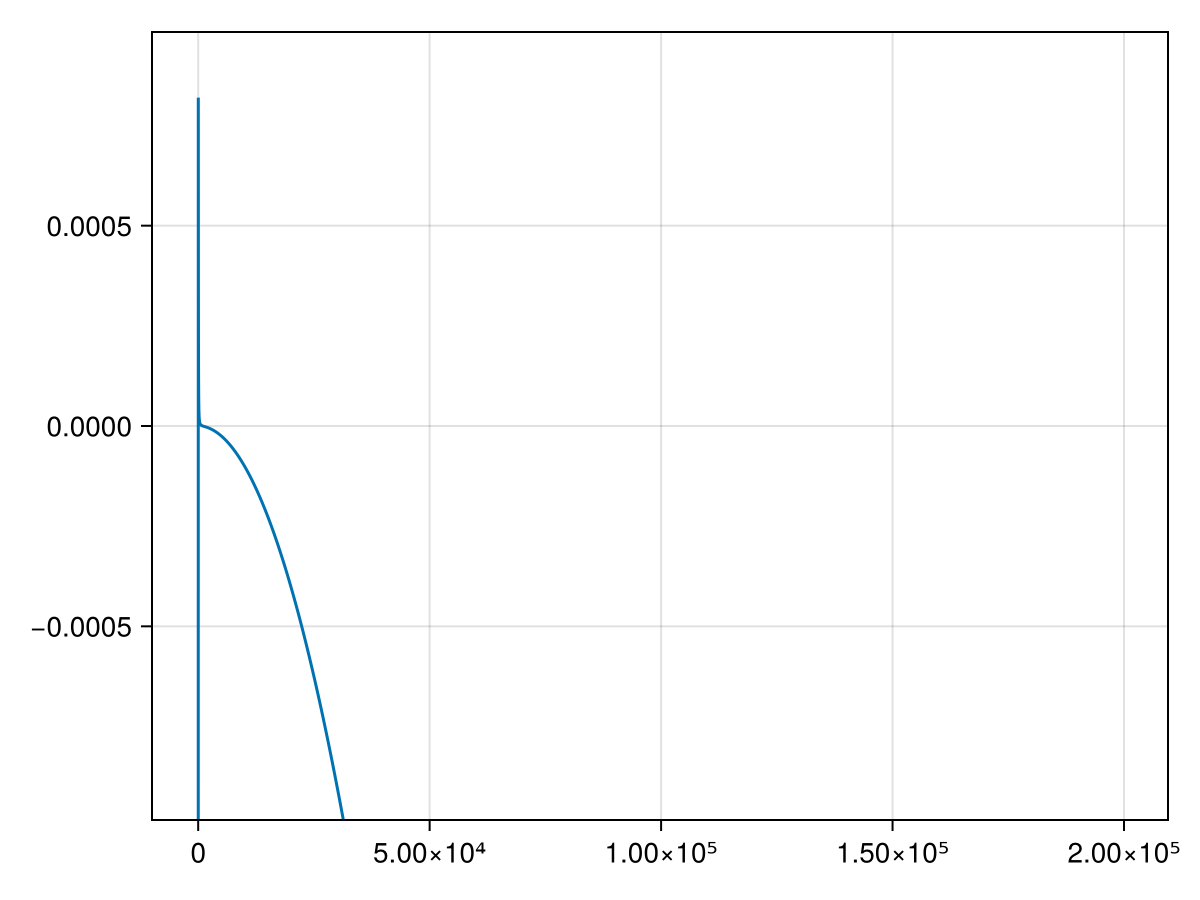

In [140]:
f = linstab_make_k_func(ps, ss; returnobj=:maxeval)
lsks=10 .^ range(-8, 5.3, 10000)
# lsks=range(1e2, 1e4, 10000)
mrls = f.(lsks)
fap = lines(lsks, mrls)

mmrl = maximum(mrls)
ylims!(fap.axis, (-1.2, 1.2) .* abs(mmrl))
# ylims!(fap.axis, (-10.2, 1.2) .* abs(mmrl))

# display(GLMakie.Screen(), fap.figure)
# Makie.save("si_interesting_disprel.pdf", fap.figure)
fap

In [35]:
jldsave("../../data/forfigures/fig1/si_li1.jld2"; N, M, B, Ks, li1df, li1cdf, li1cms=l1cms)

# Load linstab data (takes ~3min)

In [4]:
f = jldopen("../../cluster_env/runs/single_influx/gd5_forfigures_260212_153215.jld2");
Ks, lis, rslts = make_Kli_matrix(f);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


In [5]:
f2 = jldopen("../../data/forfigures/fig1/si_li1.jld2")
li1df = f2["li1df"]
li1cdf = f2["li1cdf"];

In [6]:
rdfs = f["raw_dfs"];

# Prepping data for PDE run v1

In [144]:
f = jldopen("../../cluster_env/runs/single_influx/gd5_forfigures_260212_153215.jld2");
Ks, lis, results = make_Kli_matrix_raw(f);

dominant_outcomes = map(results) do d
    mode([r.linstab_outcome for r in d])
end;

length(Ks), length(lis), size(results)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


(50, 30, (50, 30))

In [145]:
Kis_to_sample = []

lis_to_sample = 20:length(lis)

for i in lis_to_sample
    first_unstable = nothing
    last_unstable = nothing
    for j in 1:length(Ks)
        if isnothing(first_unstable) && (dominant_outcomes[j, i] == :unstable)
            first_unstable = j
        end
        if isnothing(last_unstable) && (dominant_outcomes[j, i] == :stable)
            last_unstable = j - 1
        end
    end

    step = round(Int, (last_unstable - first_unstable) / 4)
    push!(Kis_to_sample, [first_unstable, first_unstable + step, first_unstable + 2 * step, first_unstable + 3 * step, last_unstable])

#=     if isnothing(first_unstable)
        push!(Kis_to_sample, [])
    else
        diff = last_unstable - first_unstable
        if diff <= 3
            push!(Kis_to_sample, [round(Int, (first_unstable + last_unstable) / 2)])
        elseif diff <= 6
            step = round(Int, (last_unstable - first_unstable) / 2)
            push!(Kis_to_sample, [first_unstable, first_unstable + step, last_unstable])
        else
            push!(Kis_to_sample, nothing)
        end
    end =#
end

In [152]:
systems_to_run = []

for mi in 1:length(lis_to_sample)
    for K_i in Kis_to_sample[mi]
        li_i = lis_to_sample[mi]
        
        # systems = results[K_i, li_i]
        systems = results[K_i, li_i][1:20] # only do 20 at every K, li
        
        push!(systems_to_run, (;
            K=Ks[K_i], li=lis[li_i],
            systems
        ))
    end
end

total_runs = sum(systems_to_run) do x length(x.systems) end
@show total_runs;

total_runs = 1100


In [154]:
jldsave("../../cluster_env/runs/single_influx_pdes2/systems1.jld2"; systems_to_run)

In [161]:
ps = systems_to_run[1].systems[1].params

BSMMiCRMParams{Nothing, Nothing, Nothing, Float64}(BMMiCRMParams{Nothing, Float64}([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.000118553123175, 0.9990104049012168, 0.9970876955483062, 0.9998751261593726, 1.0023973309273317, 1.0024269147901428, 1.0020035200276216, 1.003478052435465, 0.998408697408732, 1.0017085073782093, 1.0002169801301641, 1.000561888873336, 0.9993566967886504, 1.0014871492799466, 1.000696275041126, 0.998070461488964, 1.0016437687853936, 0.9960760409553691, 0.9964367188817651, 1.0013151817581813], [0.0, 0.0, 0.0, 0.0, 9.319395762340777, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [1.00037425146847

In [164]:
get_Ns(ps)

(20, 20)

# Plot a sample SI dispersion relation

In [63]:
cK = Ks[22]
@show cK
xx = @subset li1df :K .== cK :lscode .== 2
@show nrow(xx)
# yy = rand(eachrow(xx));
yy = xx[1,:];

cK = 26.826957952797258
nrow(xx) = 95


In [80]:
ks = 10 .^ range(-5, 2, 2000)
lsfunc = linstab_make_k_func(yy.params, yy.steadystates)
lambdas = lsfunc.(ks);
# faa = plot_linstab_lambdas(ks, lambdas)
# display(GLMakie.Screen(), faa.figure)
# faa.figure

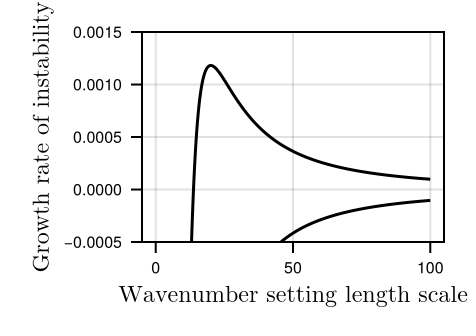

In [75]:
fig = Figure(;
    size=(double_col_width * 0.35, 0.4 * double_col_width / golden_ratio),
)
ax = Axis(fig[1,1];
    xlabel=L"\text{Wavenumber setting length scale}",
    ylabel=L"\text{Growth rate of instability}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    # ylabel=L"\lambda,\enspace\text{growth rate}",
    # xlabel=L"k,\enspace\text{wavenumber}",
)

num_lambdas = length(lambdas[1])

for li in 1:num_lambdas
    ls = getindex.(lambdas, li)

    lines!(ax, ks, real(ls);
        color=:black,
    )
end

ylims!(ax, -0.0005, 0.0015)

Makie.save("../../figures/fig1/disprel_si_sample.pdf", fig)

fig

# Proportions plot

In [24]:
li1xx = [(; extinct=r.extinct, nonext_stable=r.nonext_stable, nonext_unstable=r.nonext_unstable, num_runs=r.num_runs) for r in eachrow(li1cdf)];

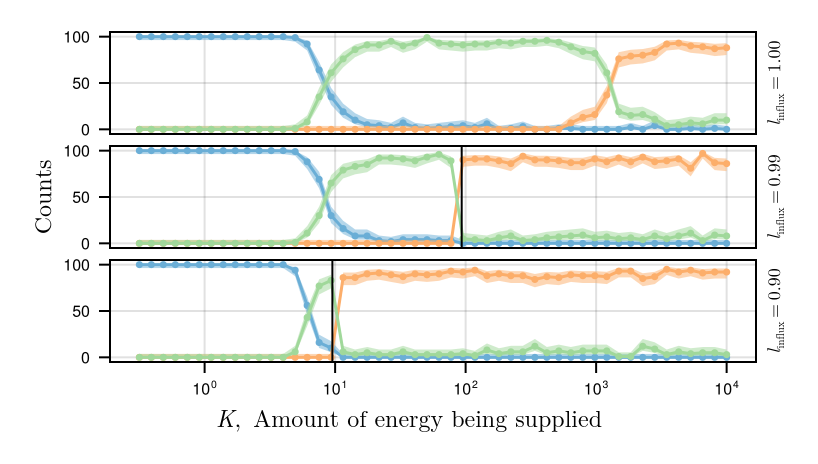

In [122]:
faflis = [1.]
fafcounts = Any[li1xx]

for i in [length(lis)-10, length(lis)-20]
    push!(faflis, lis[i])
    push!(fafcounts, rslts[:,i])
end

fig = Figure(;
   size=(double_col_width * 0.60, 0.55 * double_col_width / golden_ratio),
)

axs = []
for i in 1:length(faflis)
    li = faflis[i]
    cs = fafcounts[i]

    ax = Axis(fig[i,1];
        xscale=log10,
        xticklabelsize=6fontsize_pt,
        yticklabelsize=6fontsize_pt,
    )
    ylims!(ax, -5, 105)
    push!(axs, ax)
    Label(fig[i,2], latexstring(@sprintf "l_\\text{influx}=%.2f" li);
        rotation=pi/2,
        tellheight=false,
        fontsize=6fontsize_ltex_pt,
    )
    
    num_runs = [x.num_runs for x in cs]
    plot_binom_sample!(ax, Ks, [x.extinct for x in cs], num_runs;
        color=PaperColors.extinct1(),
        sl_kwargs=(; markersize=5.),
    )
    plot_binom_sample!(ax, Ks, [x.nonext_stable for x in cs], num_runs;
        color=PaperColors.stable1(),
        sl_kwargs=(; markersize=5.),
    )
    plot_binom_sample!(ax, Ks, [x.nonext_unstable for x in cs], num_runs;
        color=PaperColors.unstable1(),
        sl_kwargs=(; markersize=5.),
    )
        
    thrbdr = 1 / (1 - li)
    if isfinite(thrbdr)
        vlines!(ax, thrbdr;
            color=:black,
            linewidth=1.,
        )
    end
end

for i in 1:(length(axs)-1)
    linkxaxes!(axs[end], axs[i])
    hidexdecorations!(axs[i]; grid=false)
end

Label(fig[:,0], L"\text{Counts}";
    rotation=pi/2,
    tellheight=false,
    fontsize=8fontsize_ltex_pt,
)

Label(fig[end+1,:], L"K,\enspace\text{Amount of energy being supplied}";
    tellwidth=false,
    fontsize=8fontsize_ltex_pt,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 5.)

Makie.save("../../figures/fig1/proportions.pdf", fig)

fig

# Plotting dominant states as a K vs l phase diagram

In [7]:
extrema(1 .- lis)

(0.0010000000000000009, 0.5)

In [8]:
dominant = map(rslts) do x
    am = argmax([x.extinct, x.nonext_unstable, x.nonext_stable])
    if am == 1
        PaperColors.extinct1()
    elseif am == 2
        PaperColors.unstable1()
    else
        PaperColors.stable1()
    end
end;

In [9]:
default_fig_kwargs = (;
    fontsize=6fontsize_pt,
    markersize=6,
    figure_padding=(2, 2, 2, 2)
)

(fontsize = 8.0, markersize = 6, figure_padding = (2, 2, 2, 2))

In [17]:
import SSMCMain.ModifiedMiCRM.MinimalModelV2

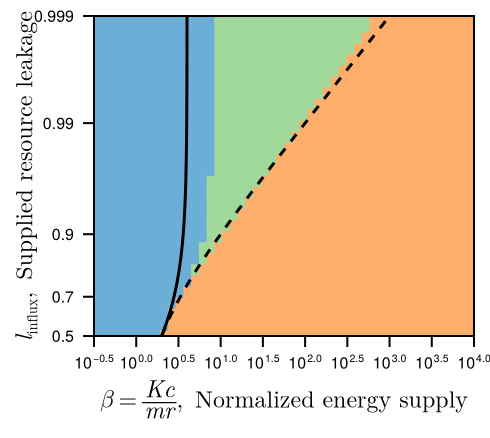

In [ ]:
plotlines = false

fig = Figure(;
    size=(double_col_width * 0.4, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(2., 5., 2., 2.),
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

leakxs = LeakageScale.ltox.(lis)
heatmap!(ax, Ks, leakxs, dominant)

if plotlines
    p = 1.

    thr_leakxs = range(extrema(leakxs)..., 1000)
    thr_ls = LeakageScale.l.(thr_leakxs)

    extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)
    instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p)

    lines!(ax, extline_Ks, thr_leakxs;
        color=:black,
    )
    lines!(ax, instabline_Ks, thr_leakxs;
        color=:black,
        linestyle=:dash,
    )

    xlims!(ax, extrema(Ks))
    ylims!(ax, extrema(leakxs))
end

eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1-e)) for e in eps_ticks])
# ax.ylabel = L"l_\text{influx},\enspace\text{Leakage of influx resource}"
ax.ylabel = L"l_\text{influx},\enspace\text{Supplied resource leakage}"
ax.xlabel = L"K,\enspace\text{Amount of energy being supplied}"
# ax.xlabel = L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}"

ax.ylabelpadding = -3.

Makie.save("../../figures/fig1_si/K_vs_l_pd.pdf", fig)
# Makie.save("../../figures/fig1_si/K_vs_l_pd_for_poster.pdf", fig)

fig

# Extras 1

In [7]:
f = jldopen("../../cluster_env/runs/single_influx2/m1260310_175653.jld2");
Kmcrs = f["Kmcrs"]
results = f["results"];

In [8]:
results

8-element Vector{Any}:
 (extinct = 10, nonext_stable = 0, nonext_unstable = 0, bad_ss = 0, good_ss_bad_ls = 0)
 (extinct = 0, nonext_stable = 10, nonext_unstable = 0, bad_ss = 0, good_ss_bad_ls = 0)
 (extinct = 0, nonext_stable = 7, nonext_unstable = 1, bad_ss = 2, good_ss_bad_ls = 0)
 (extinct = 10, nonext_stable = 0, nonext_unstable = 0, bad_ss = 0, good_ss_bad_ls = 0)
 (extinct = 10, nonext_stable = 0, nonext_unstable = 0, bad_ss = 0, good_ss_bad_ls = 0)
 (extinct = 0, nonext_stable = 9, nonext_unstable = 1, bad_ss = 0, good_ss_bad_ls = 0)
 (extinct = 5, nonext_stable = 0, nonext_unstable = 3, bad_ss = 2, good_ss_bad_ls = 0)
 (extinct = 10, nonext_stable = 0, nonext_unstable = 0, bad_ss = 0, good_ss_bad_ls = 0)

4-element Vector{String}:
 "metadata"
 "Kmcrs"
 "rsgs"
 "results"